# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;warnings.filterwarnings("ignore")
import netCDF4 as nc4;        import pandas as pd
import pathlib as pl;         import os
import numpy as np;           import xarray as xr
import geopandas as gpd;
from scipy import sparse
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from functools import partial
from scipy.signal import find_peaks
from scipy.sparse import coo_matrix
from shapely.geometry import Point
import ternary

In [2]:

def compute_keep_idx2(
    sample_path,
    min_depth,
    max_depth,
    bbox=None,
):
    """
    Return indices of nodes whose depth is between min_depth and max_depth,
    optionally also lying within a bounding box in x/y.

    Parameters
    ----------
    sample_path : str or Path
        Path to a CF‑ified fort.63 file.
    min_depth, max_depth : float
        Depth range (inclusive) in meters.
    bbox : tuple of floats (min_x, max_x, min_y, max_y), optional
        If given, further restrict to nodes with:
           min_x <= x <= max_x  AND  min_y <= y <= max_y.

    Returns
    -------
    keep_idx : np.ndarray of int
        Indices of the `node` dimension satisfying your criteria.
    """
    ds0 = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    
    # 1) depth mask
    depth = ds0.depth.values
    fv    = ds0.depth.encoding.get("_FillValue", None)
    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth)
    mask &= (depth <= max_depth)

    # 2) optional bbox mask
    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x = ds0.x.values
        y = ds0.y.values
        mask &= (x >= min_x) & (x <= max_x)
        mask &= (y >= min_y) & (y <= max_y)

    ds0.close()
    return np.where(mask)[0]

In [3]:
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140

In [4]:
root = '/scratch/tmiesse/project/data4spatial'
YEARS = range(1980, 2025)
MIN_DEPTH = 0.25
MAX_DEPTH = 1.25
bbox = (lon1, lon2, lat1, lat2)
sample_path = f"{root}/2023/fort.63.cf.nc"
keep_idx = compute_keep_idx2(
    sample_path=sample_path,
    min_depth=MIN_DEPTH,
    max_depth=MAX_DEPTH,
    bbox=bbox
)
print(f"Keeping {len(keep_idx)}")

Keeping 49253


In [5]:
from dask.distributed import Client, LocalCluster
import math
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")




In [6]:
cluster = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu,
    memory_target_fraction=0.8,
    memory_spill_fraction=0.9)

client = Client(cluster)
print(client)

/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker_memory.py:508: FutureWarning: Parameter memory_target_fraction has been deprecated and will be removed in a future version; please use dask config key distributed.worker.memory.target instead
  warnings.warn(
/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker_memory.py:508: FutureWarning: Parameter memory_target_fraction has been deprecated and will be removed in a future version; please use dask config key distributed.worker.memory.target instead
  warnings.warn(
/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker_memory.py:508: FutureWarning: Parameter memory_target_fraction has been deprecated and will be removed in a future version; please use dask config key distributed.worker.memory.target instead
  warnings.warn(
/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker_memory.py:508: FutureWarning:

<Client: 'tcp://127.0.0.1:37455' processes=45 threads=45, memory=2.95 TiB>


In [7]:
def preprocess(ds):
    # 1) decode raw time → pandas
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) drop anything outside that calendar year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    #ds = ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
    # 3) drop the spin‑up
    ds = ds.isel(time=mask)
    # 4) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    return ds
def preprocess_light(ds):
    # 1) decode time → pandas
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) keep only that calendar year
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    ds = ds.isel(time=mask)
    # 3) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    # 4) drop everything except 'zeta'
    return ds[['zeta']]

In [8]:
paths = [str(pl.Path(root)/str(y)/"fort.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['zeta'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal"                  # minimal coords → time, node, x, y
)

times  = ds_all.time.values      # length T
z = ds_all.zeta.values
#z = ds_all.zeta.values.astype(float)
x_all  = ds_all.x.values                          # (n_nodes,)
y_all  = ds_all.y.values                          # (n_nodes,)


In [9]:
paths = [str(pl.Path(root)/str(y)/"fort.93.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess,
            combine="nested",
            concat_dim="time",
            chunks={'time':24})
ice = ds_all.iceaf.values
time_ice  = ds_all.time.values      # length T

ds_all.close()

In [10]:
paths = [str(pl.Path(root)/str(y)/"fort.73.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess,
            combine="nested",
            concat_dim="time",
            chunks={'time':24})
press = ds_all.pressure.values
time_press  = ds_all.time.values      # length T

ds_all.close()

In [11]:
def preprocess2(ds):
    # 1) decode raw time → pandas datetime
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    # 2) keep only the calendar year (drop spin-up before)
    year = ds.time.dt.year.values[600]  # sample index to get year
    mask = ds.time.dt.year == year
    ds = ds.isel(time=mask)
    # 3) subset to shallow nodes
    ds = ds.isel(node=keep_idx)
    # 4) drop x,y if present (to allow concatenation)
    ds = ds.drop_vars(['x','y'], errors='ignore')
    return ds

In [12]:
paths = [str(pl.Path(root)/str(y)/"fort.74.cf.nc") for y in YEARS]
ds_all =  xr.open_mfdataset(
            paths,
            engine="h5netcdf",            # <- use h5netcdf instead of netcdf4
            mask_and_scale=True,   # ← automatically turn fill‐values into NaN
            decode_cf=True,        # ← apply CF conventions (including _FillValue)
            preprocess=preprocess2,
            combine="nested",
            concat_dim="time",
            chunks={'time':24})
windx = ds_all.windx.values
windy = ds_all.windy.values
time_wind  = ds_all.time.values      # length T


In [13]:
from dask.diagnostics import ProgressBar

# assume ds_all is already your open_mfdataset(…, chunks={'time':24}, …)
# with windx and windy on dims (time,node)

# 1) Build wind_speed lazily (still chunked time=24, full node axis)
wind_speed = xr.ufuncs.sqrt(ds_all['windx']**2 + ds_all['windy']**2) \
                   .rename('wind_speed')

# 2) Kick off the parallel compute+cache on your 45-worker cluster
with ProgressBar():
    wind_speed = wind_speed.persist()


In [15]:
da_zeta = xr.DataArray(
    z,
    dims=('time','node'),
    coords={'time': times, 'node': ds_all.node},
    name='zeta'
)

da_ice = xr.DataArray(
    ice,
    dims=('time','node'),
    coords={'time': time_ice, 'node': ds_all.node},
    name='sea_ice'
)

da_press = xr.DataArray(
    press,
    dims=('time','node'),
    coords={'time': time_press, 'node': ds_all.node},
    name='pressure'
)
wind_speed.name = 'wind_speed'

In [16]:
da_zeta_mon   = da_zeta.resample(time='M').max()
da_ice_mon    = da_ice.resample(time='M').max()
da_press_mon  = da_press.resample(time='M').min()
da_wind_mon   = wind_speed.resample(time='M').max()

In [17]:
ds_monthly = xr.merge([
    da_zeta_mon.to_dataset(),
    da_ice_mon.to_dataset(),
    da_press_mon.to_dataset(),
    da_wind_mon.to_dataset()
])

In [21]:
import ruptures as rpt

# 1) Load your monthly max dataset

# dims = ('time','node')

# 2) Extract the times and the DataArray we’ll analyze
times = ds_monthly['time'].values     # array of numpy.datetime64
zeta  = ds_monthly['zeta']            # (time, node)

def detect_cp_monthly(y, times, n_bkps=1):
    # 1) Mask NaNs
    idx = np.where(~np.isnan(y))[0]
    if idx.size < 6:
        return np.datetime64("NaT")

    arr = y[idx].astype(float)
    # 2) Try the rupture; on *any* error bail out
    try:
        algo = rpt.Binseg(model="rbf").fit(arr.reshape(-1,1))
        bkps = algo.predict(n_bkps=n_bkps)
        cp   = bkps[0]
    except Exception:
        return np.datetime64("NaT")

    # 3) If break is interior, return its timestamp
    if 0 < cp < len(arr):
        return times[idx[cp]]
    return np.datetime64("NaT")

# 3) Vectorize over the node dimension
da_inf = xr.apply_ufunc(
    detect_cp_monthly,
    zeta,
    input_core_dims=[['time']],
    output_core_dims=[[]],          # scalar per node
    vectorize=True,
    kwargs={'times': times},
    dask='parallelized',
    output_dtypes=['datetime64[ns]'])

In [22]:
# 4) Clean up coords & name
da_inf = da_inf.rename('inflection_date').assign_coords({
    'node': ds_monthly['node'],
    'x':     ('node', x_all),
    'y':     ('node', y_all),
})

# 5) Wrap and save
ds_inf_mon = da_inf.to_dataset()
outpath = '/scratch/tmiesse/project/inflection_monthly.nc'
ds_inf_mon.to_netcdf(outpath, format='NETCDF4', engine='h5netcdf')

In [23]:
from scipy.stats import pearsonr
nnode = ds_inf_mon.dims['node']
times = ds_monthly['time'].values

# 3) Pull inflection dates per node
inf_dates = ds_inf_mon['inflection_date'].values  # shape (node,)

# 4) Prepare output arrays for normalized importances
pre_frac_ice  = np.full((nnode,), np.nan)
pre_frac_wind = np.full((nnode,), np.nan)
pre_frac_pres = np.full((nnode,), np.nan)
post_frac_ice  = np.full((nnode,), np.nan)
post_frac_wind = np.full((nnode,), np.nan)
post_frac_pres = np.full((nnode,), np.nan)

# 5) Pull monthly arrays into memory
zeta_arr = ds_monthly['zeta'].values          # shape (time, node)
ice_arr  = ds_monthly['sea_ice'].values
wind_arr = ds_monthly['wind_speed'].values
pres_arr = ds_monthly['pressure'].values

# 6) Loop over each node
for i in range(nnode):
    cut = inf_dates[i]
    if np.isnat(cut):
        continue  # skip nodes with no inflection

    # Boolean masks
    pre_mask  = times <  cut
    post_mask = times >= cut

    # Helper to compute normalized importance
    def compute_importance(mask):
        # require at least 4 valid pairs per segment
        if mask.sum() < 4:
            return (np.nan, np.nan, np.nan)
        # compute Pearson r for each driver
        rs = []
        for arr in (ice_arr, wind_arr, pres_arr):
            x = zeta_arr[mask, i]
            y = arr[mask, i]
            valid = np.isfinite(x) & np.isfinite(y)
            if valid.sum() < 4:
                rs.append(0.0)
            else:
                rs.append(abs(pearsonr(x[valid], y[valid])[0]))
        total = sum(rs)
        if total > 0:
            return tuple(r/total for r in rs)
        else:
            return (0.0, 0.0, 0.0)

    # Compute pre- and post-inflection importances
    pre_i, pre_w, pre_p = compute_importance(pre_mask)
    post_i, post_w, post_p = compute_importance(post_mask)

    pre_frac_ice[i]  = pre_i
    pre_frac_wind[i] = pre_w
    pre_frac_pres[i] = pre_p
    post_frac_ice[i]  = post_i
    post_frac_wind[i] = post_w
    post_frac_pres[i] = post_p

# 7) Build an xarray Dataset
ds_imp = xr.Dataset({
    'pre_frac_ice':  (('node',), pre_frac_ice),
    'pre_frac_wind': (('node',), pre_frac_wind),
    'pre_frac_pres': (('node',), pre_frac_pres),
    'post_frac_ice':  (('node',), post_frac_ice),
    'post_frac_wind': (('node',), post_frac_wind),
    'post_frac_pres': (('node',), post_frac_pres),
}, coords={
    'node': ds_inf_mon['node'],
    'x': ('node', ds_inf_mon['x'].values),
    'y': ('node', ds_inf_mon['y'].values),
    'inflection_date': ('node', inf_dates)
})

AttributeError: 'tuple' object has no attribute 'boundary'

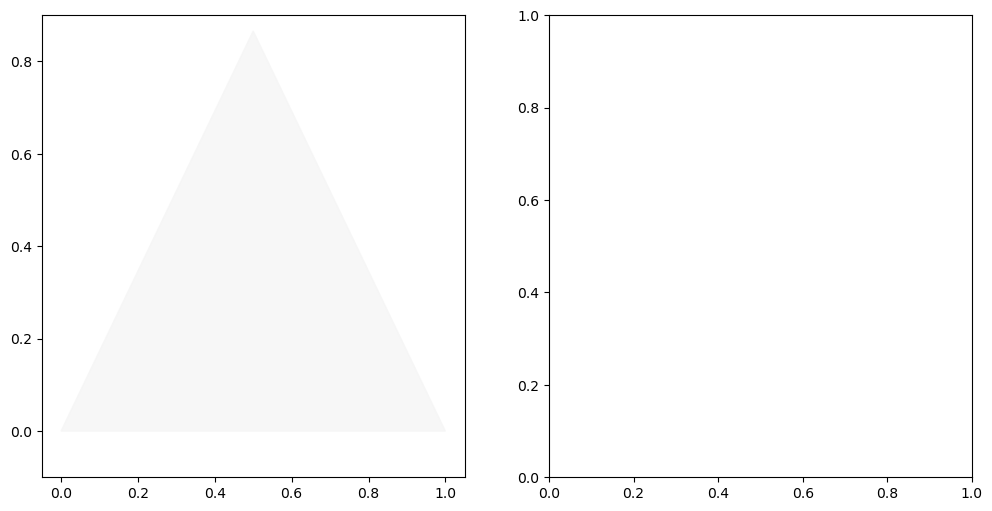

In [ ]:
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Stack into (3, nnode) arrays
frac_pre  = np.vstack([ds_imp.pre_frac_ice .values,
                       ds_imp.pre_frac_wind.values,
                       ds_imp.pre_frac_pres.values])
frac_post = np.vstack([ds_imp.post_frac_ice .values,
                       ds_imp.post_frac_wind.values,
                       ds_imp.post_frac_pres.values])

# ── 2) Compute Cartesian coords & KDE for each so we can pick a common vmin/vmax ────
def get_density(frac):
    l1,l2,l3 = frac
    x = l2 + l3/2
    y = l3 * (np.sqrt(3)/2)
    valid = np.isfinite(x)&np.isfinite(y)
    coords = np.vstack([x[valid], y[valid]])
    kde    = st.gaussian_kde(coords)
    dens   = kde(coords)
    return x, y, valid, dens

_,_,_,dens_pre  = get_density(frac_pre)
_,_,_,dens_post = get_density(frac_post)
vmin, vmax = 0,20#min(dens_pre.min(), dens_post.min()), max(dens_pre.max(), dens_post.max())

# ── 3) Build the 1×2 figure and plot each panel ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for ax, frac, title in zip(
    (ax1, ax2),
    (frac_pre, frac_post),
    ("Pre-Inflection Importances", "Post-Inflection Importances")
):
    # replicate your original python-ternary calls but passing ax=...
    scale = 1.0
    fig_dummy, tax = ternary.figure(scale=scale, ax=ax)
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=0.2, color="gray", linestyle="--")
    tax.ax.axis('off')
    tax.ticks(axis='lbr', multiple=0.2, linewidth=1,
              tick_formats="%.1f", offset=0.02)

    tax.bottom_axis_label("Pressure", offset=0.025, fontsize=12)
    tax.left_axis_label  ("Wind",     offset=0.1, rotation=60,  fontsize=12)
    tax.right_axis_label ("Sea Ice", offset=0.09, rotation=-60, fontsize=12)

    # get coords & density for this panel
    x, y, valid, density = get_density(frac)
    points = [(l1, l2, l3) for l1,l2,l3,ok in zip(*frac, valid) if ok]
    tax.scatter(
        points,
        c=density,
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        marker='o',
        s=5,
        alpha=0.7
    )

    tax.ax.set_title(title, pad=10, fontsize=14)

# ── 4) Add a single, shared vertical colorbar ────────────────────────────────
sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap='viridis')
sm.set_array([])
cax = fig.add_axes([0.99, 0.1, 0.02, 0.82])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Point Density', fontsize=12)

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density_v2.png', dpi=300,bbox_inches='tight')
plt.show()

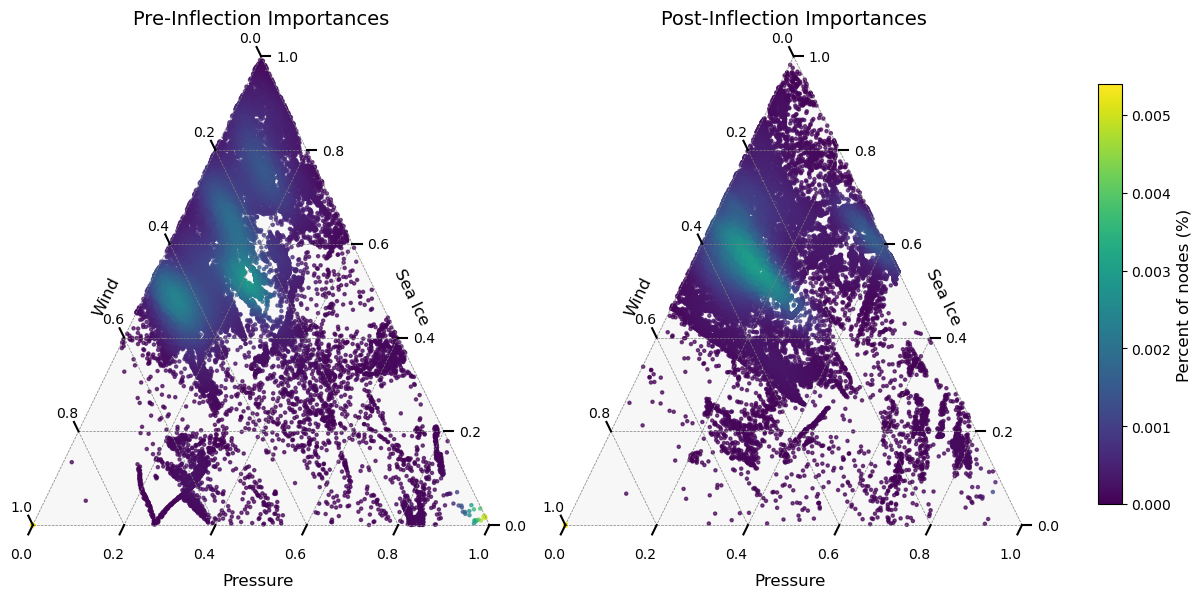

In [27]:
frac_pre  = np.vstack([
    ds_imp.pre_frac_ice .values,
    ds_imp.pre_frac_wind.values,
    ds_imp.pre_frac_pres.values
])
frac_post = np.vstack([
    ds_imp.post_frac_ice .values,
    ds_imp.post_frac_wind.values,
    ds_imp.post_frac_pres.values
])

# 2) Compute Cartesian coords & percent-density via KDE
def get_pct_density(frac):
    l1, l2, l3 = frac
    x = l2 + l3 / 2
    y = l3 * (np.sqrt(3) / 2)
    valid = np.isfinite(x) & np.isfinite(y)
    coords = np.vstack([x[valid], y[valid]])
    kde   = st.gaussian_kde(coords)
    dens  = kde(coords)
    pct   = dens / dens.sum() * 100
    return x, y, valid, pct

x_pre,  y_pre,  valid_pre,  pct_pre  = get_pct_density(frac_pre)
x_post, y_post, valid_post, pct_post = get_pct_density(frac_post)

# 3) Shared color scale limits
vmin, vmax = 0, max(pct_pre.max(), pct_post.max())

# 4) Create figure with two ternary subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for ax, title in zip((ax1, ax2),
                     ("Pre-Inflection Importances", "Post-Inflection Importances")):
    # pick the right data
    if ax is ax1:
        frac, valid, pct = frac_pre, valid_pre, pct_pre
    else:
        frac, valid, pct = frac_post, valid_post, pct_post

    # set up ternary axes on this subplot
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=1.0)
    tax.boundary(linewidth=0)
    tax.gridlines(multiple=0.2, color="gray", linestyle="--")
    tax.clear_matplotlib_ticks()
    tax.ax.set_frame_on(False)
    tax.ticks(axis='lbr', multiple=0.2, tick_formats="%.1f", offset=0.02)

    # side labels
    tax.bottom_axis_label("Pressure", offset=0.025, fontsize=12)
    tax.left_axis_label  ("Wind",     offset=0.10, rotation=60,  fontsize=12)
    tax.right_axis_label ("Sea Ice",  offset=0.09, rotation=-60, fontsize=12)

    # build the list of (l1,l2,l3) points for valid nodes
    l1_vals, l2_vals, l3_vals = frac
    points = [(l1_vals[i], l2_vals[i], l3_vals[i])
              for i, ok in enumerate(valid) if ok]

    # scatter with percent-of-nodes coloring
    tax.scatter(
        points,
        c=pct,
        cmap='viridis',
        vmin=vmin, vmax=vmax,
        marker='o',
        s=5,
        alpha=0.7
    )
    tax.ax.set_title(title, pad=10, fontsize=14)

# 5) Add a single vertical colorbar to the right
sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap='viridis')
sm.set_array([])
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Percent of nodes (%)', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('/scratch/tmiesse/project/figures/ternary_density_v4.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

outpath = '/groups/ORC-CLIMATE/fhrl_repo/Arctic_Database/data4analysis/monthly_data.nc'
encoding = {var: {'zlib': True, 'complevel': 4} for var in ds_monthly.data_vars}
ds_monthly.to_netcdf(outpath)#, format='NETCDF4', engine='h5netcdf', encoding=encoding)

In [ ]:
wse = ds_monthly['zeta'].values
sic = ds_monthly['sea_ice'].values
ws  = ds_monthly['wind_speed'].values
pr  = ds_monthly['pressure'].values


In [ ]:
nnode = wse.shape[1]

# 3) Compute Pearson correlation per node safely
corr_sic = np.empty(nnode)
corr_ws  = np.empty(nnode)
corr_pr  = np.empty(nnode)

for i in range(nnode):
    xi = wse[:, i]
    yi = sic[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_sic[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan

    yi = ws[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_ws[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan

    yi = pr[:, i]
    mask = np.isfinite(xi) & np.isfinite(yi)
    corr_pr[i] = np.corrcoef(xi[mask], yi[mask])[0, 1] if mask.sum() > 1 else np.nan



In [ ]:
# 4) Absolute correlations → normalized importances
imp = np.vstack((np.abs(corr_sic), np.abs(corr_ws), np.abs(corr_pr)))  # shape (3, nnode)
sum_imp = imp.sum(axis=0)
frac = imp / sum_imp  # each column sums to 1

In [ ]:
#imp = np.vstack((np.abs(corr_sic), np.abs(corr_ws), np.abs(corr_pr)))  # shape (3, nnode)
#sum_imp = imp.sum(axis=0)
#frac = imp / sum_imp  # each column sums to 1; rows = [seaice, wind, pressure]

l1, l2, l3 = frac  # l1=seaice, l2=wind, l3=pressure
x_tri = l2 + l3/2
y_tri = l3 * (np.sqrt(3)/2)

In [ ]:
import ternary
import matplotlib.pyplot as plt
scale = 1.0  # normalized sums
fig, tax = ternary.figure(scale=scale)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray", linestyle="--")


tax.left_corner_label("Sea Ice",   offset=0.16)
tax.right_corner_label("Wind",     offset=0.16)
tax.top_corner_label("Pressure",   offset=0.08)

# 3) Plot each node
points = list(zip(frac[0], frac[1], frac[2]))  # (s,w,p) tuples
tax.scatter(points, marker='o', color='C0', s=5, alpha=0.4)

# 4) Ticks & styling
tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
tax.clear_matplotlib_ticks()
tax.ax.set_title("Relative Importance of Forcing on WSE Extremes", pad=20)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 1) Compute barycentric coords and mask invalids
l1, l2, l3 = frac
x = l2 + l3/2
y = l3 * (np.sqrt(3)/2)
valid = np.isfinite(x) & np.isfinite(y)
xv, yv = x[valid], y[valid]

# 2) KDE for density
coords  = np.vstack([xv, yv])
kde     = st.gaussian_kde(coords)
density = kde(coords)

vmin, vmax = density.min(), density.max()

# 3) Build ternary figure
scale = 1.0
fig, tax = ternary.figure(scale=scale)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray", linestyle="--")
tax.left_corner_label("Sea Ice", offset=0.16)
tax.right_corner_label("Wind",   offset=0.16)
tax.top_corner_label("Pressure", offset=0.16)

# 4) Original base scatter in light gray (optional)
points_all = list(zip(l1, l2, l3))
tax.scatter(points_all, marker='o', color='lightgray', s=5, alpha=0.3)

# 5) Density‐colored scatter on valid points
points_valid = [(l1[i], l2[i], l3[i]) for i in np.nonzero(valid)[0]]
tax.scatter(
    points_valid,
    marker='o',
    c=density,
    cmap='viridis',
    vmin=vmin, vmax=vmax,  # pass vmin/vmax instead of norm
    s=5,
    alpha=0.7
)

# 6) Ticks & styling
tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
#tax.clear_matplotlib_ticks()
#tax.ax.set_title(
#    "Relative Importance of Forcing on WSE Extremes\n(Colored by Density)",
#    pad=20
#)

# 7) Add a colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin, vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=tax.ax, orientation='vertical', pad=0.1)
cbar.set_label("Point Density")

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import ternary
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# — assume frac is already defined (shape 3×nnode) —
l1, l2, l3 = frac

# Convert to Cartesian coords
x = l2 + l3/2
y = l3 * (np.sqrt(3)/2)
valid = np.isfinite(x) & np.isfinite(y)
inds  = np.nonzero(valid)[0]

# KDE for density
coords = np.vstack([x[inds], y[inds]])
kde = st.gaussian_kde(coords)
density = kde(coords)
vmin, vmax = density.min(), density.max()

# Build ternary plot
scale = 1.0
fig, tax = ternary.figure(scale=scale)
# Remove the default triangle border if you want no box around plot:
tax.boundary(linewidth=0)  

# Add grid lines
tax.gridlines(multiple=0.2, color="gray", linestyle="--")

# Remove the outer Matplotlib axes/frame entirely
tax.ax.axis('off')

# Set ticks on each side every 0.2 with proper labels
tax.ticks(
    axis='lbr', 
    multiple=0.2, 
    linewidth=1, 
    tick_formats="%.1f",
    offset=0.02
)

# Corner labels
tax.bottom_axis_label("Pressure", offset=0.025, fontsize=12)

# Side between Sea Ice & Pressure = Wind axis → left slanted side
tax.left_axis_label("Wind", offset=0.1, rotation=60,fontsize=12)

# Side between Wind & Pressure = Sea Ice axis → right slanted side
tax.right_axis_label("Sea Ice", offset=0.09, rotation=-60, fontsize=12)
# Plot density‐colored points
points = [(l1[i], l2[i], l3[i]) for i in inds]
tax.scatter(
    points,
    c=density,
    cmap='viridis',
    vmin=vmin, vmax=vmax,
    marker='o',
    s=5,
    alpha=0.7
)

# Colorbar
sm = ScalarMappable(cmap='viridis', norm=Normalize(vmin, vmax))
sm.set_array([])
#cbar = fig.colorbar(sm, ax=tax.ax, orientation='vertical', pad=0.1)
#cbar.set_label("Point Density")

plt.tight_layout()
plt.savefig('/scratch/tmiesse/project/figures/ternary_density.png', dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.hist(frac[2], bins=30, density=False)
plt.xlabel("Pressure importance (ℓ₃)")
plt.ylabel("Number of nodes")
plt.show()

In [ ]:
frac[2]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = np.stack([SIC_it, WS_it, P_it], axis=1)   # shape (T,3)
y = WSE_it                                   # shape (T,)

model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X, y)
imp = model.feature_importances_            # e.g. [0.2, 0.5, 0.3]

In [ ]:
imp = imp / imp.sum()    # now imp = [si, wi, pi], si+wi+pi = 1

In [ ]:
figure, tax = ternary.figure(scale=1.0)
tax.boundary(linewidth=1.0)
tax.gridlines(multiple=0.2, color="gray")

# label the corners
tax.left_corner_label("Sea Ice")
tax.right_corner_label("Pressure")
tax.top_corner_label("Wind")

# plot each node as a point in barycentric coords
for si, wi, pi in importances_per_node:
    tax.scatter([(si, wi, pi)], marker='o', color='blue', s=10)

tax.ticks(axis='lbr', multiple=0.2, linewidth=1)
tax.clear_matplotlib_ticks()
plt.show()